# Setup
Package installation and library loading

In [1]:
# # Only need to run these once (uncomment if needed)
# install.packages("foreign")
# install.packages("devtools")
# install.packages("tidyverse")
# install.packages("readr")
# install.packages("readxl")
# install.packages("haven")
# install.packages("dplyr")
# install.packages("gtsummary")
# isntall.packages("gt")
# install.packages("stringr")
# install.packages("survey")
# install.packages("DiagrammeR")
# install.packages("DiagrammeRsvg")
# install.packages("rsvg")

# # Run these every time you restart R:
library(foreign)
library(devtools)
library(tidyverse)
library(readr)
library(readxl)
library(haven)
library(dplyr)
library(gtsummary)
library(gt)
library(stringr)
library(survey)
library(glue)
library(DiagrammeR)
library(DiagrammeRsvg)
library(rsvg)

# only run once if needed
# install_github("sshrestha274/meps_r_pkg/MEPS")

library(MEPS)

Loading required package: usethis
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors
Loading required package: grid
Loading required package: Matrix

Attaching package: ‘Matrix’

The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack

Loading required package: survival

Attaching package: ‘survey’

The following object is masked from ‘package:graphics’:

    dotchart

Linking to librsvg 2.61.0


# Load data helper function
This function will help us download the data and save to an RDS file if we haven't already done so already.

In [2]:
# Load MEPS data for a single year and return a named list: fyc, cond, rx
load_meps_year <- function(year) {
  short_year <- substr(year, 3, 4)
  
  perwt  <- paste0("PERWT",  short_year, "F")
  ttlp   <- paste0("TTLP",   short_year, "X")
  povcat <- paste0("POVCAT", short_year)
  inscov <- paste0("INSCOV", short_year)
  insurc <- paste0("INSURC", short_year)
  totslf <- paste0("TOTSLF", short_year)
  obtotv <- paste0("OBTOTV", short_year)
  optotv <- paste0("OPTOTV", short_year)
  ipdis  <- paste0("IPDIS",  short_year)
  ipngtd <- paste0("IPNGTD", short_year)
  rxtot  <- paste0("RXTOT",  short_year)
  ertot  <- paste0("ERTOT",  short_year)
  
  vars_to_keep <- c(
    "DUPERSID", "PANEL", "VARSTR", "VARPSU", perwt, ttlp,
    "SEX", "AGE53X", "RACETHX", "MARRY53X", "REGION53",
    "EDUYRDG", "EDUCYR", povcat,
    "PCS42", "MCS42", "VPCS42", "VMCS42",
    "HAVEUS42", inscov, insurc, "MCAID53X",
    totslf, obtotv, optotv, ipdis, ipngtd, rxtot, ertot
  )
  
  fyc <- read_MEPS(year = year, type = "FYC") %>%
    select(any_of(vars_to_keep)) %>%
    rename(
      PERWT  = all_of(perwt),
      TTLP   = all_of(ttlp),
      POVCAT = all_of(povcat),
      INSCOV = all_of(inscov),
      TOTSLF = all_of(totslf),
      OBTOTV = all_of(obtotv),
      OPTOTV = all_of(optotv),
      IPDIS  = all_of(ipdis),
      IPNGTD = all_of(ipngtd),
      RXTOT  = all_of(rxtot),
      ERTOT  = all_of(ertot)
    )
  
  cond <- read_MEPS(year = year, type = "COND")
  
  rx <- read_MEPS(year = year, type = "RX")
  
  link <- read_MEPS(year = year, type = "CLNK")
  
  list(fyc = fyc, cond = cond, rx = rx, link = link)

}

save_all_years <- function(years = 2017:2023, out_file = file.path("data", "meps_all_years.rds")) {
  if (!dir.exists("data")) dir.create("data", recursive = TRUE)
  
  all_data <- list()
  for (yr in years) {
    d <- load_meps_year(yr)
    suffix <- paste0("_", yr)
    all_data[[paste0("fyc", suffix)]]  <- d$fyc
    all_data[[paste0("cond", suffix)]] <- d$cond
    all_data[[paste0("rx", suffix)]]   <- d$rx
    all_data[[paste0("link", suffix)]] <- d$link
  }
  
  saveRDS(all_data, file = out_file)
  invisible(out_file)
}

In [3]:
# Save the MEPS data into an accessible format

# save_all_years()

# Data cleaning
1. Read in the datasets of interest
2. Clean the FYC data which contains demographic data
3. Sort through the NDC FDA data to get drug classes
4. USE CLINK files to link ADHD dx-specific rx
5. Merge datasets

## Read and clean dataset

In [4]:
all_data <- readRDS(file.path("data", "meps_all_years.rds"))

years_of_interst <- c(2019, 2021)

for (year in years_of_interst) {
  assign(paste0("fyc_", year), all_data[[paste0("fyc_", year)]])
  assign(paste0("cond_", year), all_data[[paste0("cond_", year)]])
  assign(paste0("rx_", year), all_data[[paste0("rx_", year)]])
  assign(paste0("link_", year), all_data[[paste0("link_", year)]])
}

rm(all_data)
gc()

           used  (Mb) gc trigger   (Mb) limit (Mb)  max used (Mb)
Ncells  4815298 257.2   13631438  728.0         NA   9679786  517
Vcells 67344933 513.9  228590944 1744.1      16384 195945741 1495

In [5]:
# in fyc_2019, some things are inappropriately haven labelled
# convert haven labels to numeric
inappropriate_labels <- c("VPCS42", "VMCS42", "OBTOTV", "OPTOTV", "IPDIS", "IPNGTD", "ERTOT")
fyc_2019 <- fyc_2019 %>%
  mutate(across(any_of(inappropriate_labels), ~ as.numeric(as.character(.x))))
fyc_2021 <- fyc_2021 %>%
  mutate(across(any_of(inappropriate_labels), ~ as.numeric(as.character(.x))))

# convert haven labels to factors in df fyc 
# remove preceding numbers from factor levels
clean_labels <- function(x) {
  if (haven::is.labelled(x)) x <- haven::as_factor(x)
  if (is.factor(x)) levels(x) <- gsub("^[0-9]+\\s*", "", levels(x))
  x
}

fyc_2019 <- fyc_2019 %>% mutate(across(where(~ haven::is.labelled(.x) || is.factor(.x)), clean_labels))
fyc_2021 <- fyc_2021 %>% mutate(across(where(~ haven::is.labelled(.x) || is.factor(.x)), clean_labels))

In [6]:
# dollars: convert to 2021 dollars using CPI
cpi_2019  <- 256.974
cpi_2021  <- 278.802
cpi_ratio <- cpi_2021 / cpi_2019

fyc_2019$income_2021 <- fyc_2019$TTLP * cpi_ratio
fyc_2019$totslf_2021 <- fyc_2019$TOTSLF * cpi_ratio
fyc_2019$obtotv_2021 <- fyc_2019$OBTOTV * cpi_ratio
fyc_2019$optotv_2021 <- fyc_2019$OPTOTV * cpi_ratio
fyc_2019$rxtot_2021  <- fyc_2019$RXTOT  * cpi_ratio
fyc_2019$ertot_2021  <- fyc_2019$ERTOT  * cpi_ratio

fyc_2021$income_2021 <- fyc_2021$TTLP
fyc_2021$totslf_2021 <- fyc_2021$TOTSLF
fyc_2021$obtotv_2021 <- fyc_2021$OBTOTV
fyc_2021$optotv_2021 <- fyc_2021$OPTOTV
fyc_2021$rxtot_2021  <- fyc_2021$RXTOT
fyc_2021$ertot_2021  <- fyc_2021$ERTOT

In [7]:
# recode

# rename INSURC19 in fyc_2019 to INSURC
# rename INSURC21 in fyc_2021 to INSURC
fyc_2019 <- fyc_2019 %>% rename(INSURC = INSURC19)
fyc_2021 <- fyc_2021 %>% rename(INSURC = INSURC21)

recode_fyc <- function(df) {
  df %>% 
    mutate(
      sex = case_when(
        SEX == "MALE" ~ "Male",
        SEX == "FEMALE" ~ "Female",
        TRUE ~ NA_character_
      ),
      ethnicity = case_when(
        RACETHX == "HISPANIC" ~ "Hispanic",
        TRUE ~ "Non-Hispanic"
      ),
      race = case_when(
        RACETHX == "NON-HISPANIC ASIAN ONLY" ~ "Asian",
        RACETHX == "NON-HISPANIC BLACK ONLY" ~ "Black",
        RACETHX == "NON-HISPANIC OTHER RACE OR MULTIPLE RACE" ~ "Other",
        RACETHX == "NON-HISPANIC WHITE ONLY" ~ "White",
        TRUE ~ NA_character_
      ),
      race = factor(race, levels = c("White", "Black", "Asian", "Other")),
      marital = case_when(
        MARRY53X %in% c("-1 INAPPLICABLE", "-7 REFUSED", "-8 DK") ~ NA_character_,
        MARRY53X %in% c("MARRIED", "MARRIED IN ROUND") ~ "Married",
        TRUE ~ "Not married"
      ),
      REGION53 = na_if(REGION53, "-1 INAPPLICABLE"),
      education = case_when(
        EDUCYR %in% c("-1 INAPPLICABLE", "-7 REFUSED", "-8 DK", "-15 CANNOT BE COMPUTED") ~ NA_character_,
        EDUCYR %in% c("NO SCHOOL/KINDERGARTEN ONLY", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "GRADE 12") ~ "High school graduation or less",
        EDUCYR %in% c("1 YEAR COLLEGE", "2 YEARS COLLEGE", "3 YEARS COLLEGE", "4 YEARS COLLEGE", "5+ YEARS COLLEGE") ~ "College education or greater",
        TRUE ~ NA_character_
      ),
      insurance = case_when(
        INSURC %in% c("<65 UNINSURED", "65+ UNINSURED") ~ "Uninsured",
        INSURC == "<65 ANY PRIVATE" & MCAID53X != "YES" ~ "Private only",
        INSURC == "<65 ANY PRIVATE" & MCAID53X == "YES" ~ "Medicaid, with private",
        INSURC == "<65 PUBLIC ONLY" & MCAID53X == "YES" ~ "Medicaid only",
        INSURC == "<65 PUBLIC ONLY" & MCAID53X != "YES" ~ "Other public",
        INSURC == "65+ EDITED MEDICARE AND PRIVATE" & MCAID53X != "YES" ~ "Medicare, with private",
        INSURC == "65+ EDITED MEDICARE AND PRIVATE" & MCAID53X == "YES" ~ "Medicare, dual-eligible",
        INSURC == "65+ EDITED MEDICARE ONLY" & MCAID53X != "YES" ~ "Medicare only",
        INSURC == "65+ EDITED MEDICARE ONLY" & MCAID53X == "YES" ~ "Medicare, dual-eligible",
        INSURC == "65+ EDITED MEDICARE AND OTH PUB ONLY" & MCAID53X == "YES" ~ "Medicare, dual-eligible",
        INSURC == "65+ EDITED MEDICARE AND OTH PUB ONLY" & MCAID53X != "YES" ~ "Medicare, with other public",
        INSURC == "65+ NO MEDICARE AND ANY PUBLIC/PRIVATE" & MCAID53X == "YES" ~ "Medicaid, with private",
        INSURC == "65+ NO MEDICARE AND ANY PUBLIC/PRIVATE" & MCAID53X != "YES" ~ "Private only",
        INSCOV == "UNINSURED" ~ "Uninsured",
        INSCOV == "ANY PRIVATE" ~ "Private only",
        INSCOV == "PUBLIC ONLY" & MCAID53X == "YES" ~ "Medicaid only",
        INSCOV == "PUBLIC ONLY" & MCAID53X != "YES" ~ "Other public",
        TRUE ~ NA_character_
      ),
      insurance = factor(insurance, levels = c(
        "Private only",
        "Medicaid only",
        "Medicaid, with private",
        "Medicare only",
        "Medicare, with private",
        "Medicare, with other public",
        "Medicare, dual-eligible",
        "Other public",
        "Uninsured"
      )),
      medicaid = case_when(
        insurance == "Medicaid only" ~ "Medicaid only",
        insurance == "Medicaid, with private" ~ "Medicaid, with private, non-Medicare",
        TRUE ~ "No Medicaid"
      ),
      medicare = case_when(
        insurance %in% c("Medicare, with private", "Medicare, dual-eligible", "Medicare, with other public", "Medicare only") ~ "Medicare, any",
        TRUE ~ "No Medicare"
      ),
      private_ins = case_when(
        insurance == "Private only" ~ "Private only",
        TRUE ~ "Other/uninsured"
      ),
      has_insurance = case_when(
        INSCOV == "UNINSURED" ~ "No insurance",
        INSCOV %in% c("ANY PRIVATE", "PUBLIC ONLY") ~ "Has insurance",
        TRUE ~ NA_character_
      ),
      povcat = case_when(
        POVCAT %in% c("POOR/NEGATIVE", "NEAR POOR") ~ "Very low income",
        POVCAT == "LOW INCOME" ~ "Low income",
        POVCAT == "MIDDLE INCOME" ~ "Middle income",
        POVCAT == "HIGH INCOME" ~ "High income",
        TRUE ~ NA_character_
      ),
      povcat = factor(povcat, levels = c(
        "Very low income", 
        "Low income", 
        "Middle income", 
        "High income"
      )),
      region = case_when(
        REGION53 == "NORTHEAST" ~ "Northeast",
        REGION53 == "MIDWEST" ~ "Midwest",
        REGION53 == "SOUTH" ~ "South",
        REGION53 == "WEST" ~ "West",
        TRUE ~ NA_character_
      )
    )
}

fyc_2019 <- recode_fyc(fyc_2019)
fyc_2021 <- recode_fyc(fyc_2021)

## Sort through FDA NDC data to get drug names

In [8]:
# load ndc
files <- list.files("data/ndc", pattern = "\\.csv$", full.names = TRUE)

ndc_all <- files %>% 
  map_dfr(
    ~ read_csv(.x, col_types = cols(.default = col_character())),
    .id = "source_file"
  ) %>% 
  distinct() %>% 
  filter(
    str_detect(`Pharm Class`, "Central Nervous System Stimulant") |
      str_detect(
        toupper(`Proprietary Name`),
        "ATOMOXETINE|STRATTERA|VILOXAZINE|QELBREE|GUANFACINE|INTUNIV|TENEX||CLONIDINE|KAPVAY|CATAPRES"
      )
  )

ndc_all$formulation <- ifelse(
  str_detect(toupper(ndc_all$`Dosage Form`), "EXTENDED"),
  "Extended",
  "Normal"
)

ndc_stim <- ndc_all %>%
  select(
    `Proprietary Name`,
    `NDC Package Code`,
    `Dosage Form`,
    formulation
  ) %>%
  distinct()

# NDC adds - for legibility; remove to be compatible with MEPS
ndc_stim$ndc_compatible <- str_remove_all(ndc_stim$`NDC Package Code`, "-")

# add leading 0 to match MEPS RX dataset
ndc_stim <- ndc_stim %>% 
  mutate(ndc_compatible = str_pad(ndc_compatible, width = 11, side = "left", pad = "0"))

# in rx_2019 and rx_2021, remove year specific suffix (e.g., RXSF19X -> RXSF)
# year-specific vars: RXSF, RXMR, RXMD, RXPV, RXVA, RXTR, RXOF, RXSL, RXWC, RXOT, RXXP
rx_2019 <- rx_2019 %>% rename_with(~ str_remove(.x, "19X$"), matches("19X$"))
rx_2021 <- rx_2021 %>% rename_with(~ str_remove(.x, "21X$"), matches("21X$"))

# convert to 2021 dollars using CPI
cpi_2019  <- 256.974
cpi_2021  <- 278.802
cpi_ratio <- cpi_2021 / cpi_2019
rx_2019 <- rx_2019 %>%
  mutate(
    RXSF = RXSF * cpi_ratio,
    RXMR = RXMR * cpi_ratio,
    RXMD = RXMD * cpi_ratio,
    RXPV = RXPV * cpi_ratio,
    RXVA = RXVA * cpi_ratio,
    RXTR = RXTR * cpi_ratio,
    RXOF = RXOF * cpi_ratio,
    RXSL = RXSL * cpi_ratio,
    RXWC = RXWC * cpi_ratio,
    RXOT = RXOT * cpi_ratio,
    RXXP = RXXP * cpi_ratio
  )

rx_2019_ndc <- list(rx_2019 = rx_2019) %>%
  imap_dfr(
    ~ .x %>%
      left_join(ndc_stim, join_by(RXNDC == ndc_compatible), relationship = "many-to-many") %>%
      filter(!is.na(`NDC Package Code`)) %>%
      mutate(year = as.integer(str_remove(.y, "^rx_")))
  )

rx_2021_ndc <- list(rx_2021 = rx_2021) %>%
  imap_dfr(
    ~ .x %>%
      left_join(ndc_stim, join_by(RXNDC == ndc_compatible), relationship = "many-to-many") %>%
      filter(!is.na(`NDC Package Code`)) %>%
      mutate(year = as.integer(str_remove(.y, "^rx_")))
  )

# some things are inappropriately haven labelled; convert to numeric first
# and correct labels as needed

# RXBEGMM: convert to numeric and <0 to NA
rx_2019_ndc <- rx_2019_ndc %>% mutate(RXBEGMM = as.numeric(as.character(RXBEGMM)))
rx_2021_ndc <- rx_2021_ndc %>% mutate(RXBEGMM = as.numeric(as.character(RXBEGMM)))
rx_2019_ndc <- rx_2019_ndc %>% mutate(RXBEGMM = ifelse(RXBEGMM < 0, NA, RXBEGMM))
rx_2021_ndc <- rx_2021_ndc %>% mutate(RXBEGMM = ifelse(RXBEGMM < 0, NA, RXBEGMM))

# RXBEGYRX: convert to numeric and <0 to NA
rx_2019_ndc <- rx_2019_ndc %>% mutate(RXBEGYRX = as.numeric(as.character(RXBEGYRX)))
rx_2021_ndc <- rx_2021_ndc %>% mutate(RXBEGYRX = as.numeric(as.character(RXBEGYRX)))
rx_2019_ndc <- rx_2019_ndc %>% mutate(RXBEGYRX = ifelse(RXBEGYRX < 0, NA, RXBEGYRX))
rx_2021_ndc <- rx_2021_ndc %>% mutate(RXBEGYRX = ifelse(RXBEGYRX < 0, NA, RXBEGYRX))

# RXDAYSUP: convert to numeric and <0 to NA
rx_2019_ndc <- rx_2019_ndc %>% mutate(RXDAYSUP = as.numeric(as.character(RXDAYSUP)))
rx_2021_ndc <- rx_2021_ndc %>% mutate(RXDAYSUP = as.numeric(as.character(RXDAYSUP)))
rx_2019_ndc <- rx_2019_ndc %>% mutate(RXDAYSUP = ifelse(RXDAYSUP < 1, NA, RXDAYSUP))
rx_2021_ndc <- rx_2021_ndc %>% mutate(RXDAYSUP = ifelse(RXDAYSUP < 1, NA, RXDAYSUP))

# for some reason, PRN gets coded as 999; convert to NA
rx_2019_ndc <- rx_2019_ndc %>% mutate(RXDAYSUP = ifelse(RXDAYSUP == 999, NA, RXDAYSUP))
rx_2021_ndc <- rx_2021_ndc %>% mutate(RXDAYSUP = ifelse(RXDAYSUP == 999, NA, RXDAYSUP))

rx_2019_ndc <- rx_2019_ndc %>% mutate(across(where(~ haven::is.labelled(.x) || is.factor(.x)), clean_labels))
rx_2021_ndc <- rx_2021_ndc %>% mutate(across(where(~ haven::is.labelled(.x) || is.factor(.x)), clean_labels))

## Use CLINK files to link rx that have ADHD-dx diagnosis attached

In [9]:
# -----------------------------------------------------------------------------
# Code credit: https://github.com/HHS-AHRQ/MEPS/blob/master/R/workshop_exercises/cond_pmed_2020.R
#
# National totals:
#   - Total number of people w PMED purchase for ADHD
#   - Total PMED fills for ADHD
#   - Total PMED expenditures for ADHD
#
# Per-person averages among ppl with any PMED for ADHD
#   - Avg PMED fills for ADHD, by SEX and Poverty (POVCAT)
#   - Avg PMED exp for ADHD per person w/ ADHD fills, by SEX and Poverty (POVCAT)
# 
# Input files:
#   - 2019/2021 Prescribed Medicines file         rx_2019 and rx_2021
#   - 2019/2021 Conditions file                   cond_2019 and cond_2021
#   - 2019/2021 CLNK: Condition-Event Link file   link_2019 and link_2021
#   - 2019/2021 Full-Year Consolidated file       fyc_2019 and fyc_2021
# -----------------------------------------------------------------------------

# Set survey option for lonely PSUs
options(survey.lonely.psu='adjust')
options(survey.adjust.domain.lonely = TRUE)

# >> For PMED file, rename LINKIDX to EVNTIDX to merge with Conditions
rx_2019_ndc <- rx_2019_ndc %>% rename(EVNTIDX = LINKIDX)
rx_2021_ndc <- rx_2021_ndc %>% rename(EVNTIDX = LINKIDX)

# Prepare data for estimation -------------------------------------------------

# Subset condition records to ADHD (any ICD10CDX = "F90")
adhd_2019 <- cond_2019 %>% 
  filter(str_starts(ICD10CDX, "F90"))

adhd_2021 <- cond_2021 %>% 
  filter(str_starts(ICD10CDX, "F90"))

# Merge ADHD conditions with PMED file, using CLNK as crosswalk -----
# De-duplicate on EVNTIDX (so we don't 'double-count' events)

adhd_clnk_2019 <- adhd_2019 %>% 
  inner_join(link_2019, by = c("DUPERSID", "CONDIDX", "PANEL"))
adhd_clnk_2021 <- adhd_2021 %>% 
  inner_join(link_2021, by = c("DUPERSID", "CONDIDX", "PANEL"))
adhd_clnk_distinct_2019 <- adhd_clnk_2019 %>% 
  distinct(PANEL, DUPERSID, EVNTIDX, ICD10CDX, CCSR1X, EVENTYPE)
adhd_clnk_distinct_2021 <- adhd_clnk_2021 %>% 
  distinct(PANEL, DUPERSID, EVNTIDX, ICD10CDX, CCSR1X, EVENTYPE)

# apply clean_labels to adhd_clnk_distinct for PANEL variable
adhd_clnk_distinct_2019 <- adhd_clnk_distinct_2019 %>% mutate(PANEL = clean_labels(PANEL))
adhd_clnk_distinct_2021 <- adhd_clnk_distinct_2021 %>% mutate(PANEL = clean_labels(PANEL))

adhd_merged_2019 <- adhd_clnk_distinct_2019 %>% 
  inner_join(rx_2019_ndc, by = c("DUPERSID", "EVNTIDX", "PANEL"))
adhd_merged_2021 <- adhd_clnk_distinct_2021 %>% 
  inner_join(rx_2021_ndc, by = c("DUPERSID", "EVNTIDX", "PANEL"))

# QC: check that EVENTYPE = 8 PRESCRIBED MEDICINE for all rows
# TRUE


In [10]:
# QC: View top PMEDS for ADHD
adhd_merged_2019 %>% 
    count(RXDRGNAM) %>% 
    arrange(-n)

# A tibble: 7 × 2
  RXDRGNAM                          n
  <chr>                         <int>
1 AMPHETAMINE-DEXTROAMPHETAMINE   668
2 DEXMETHYLPHENIDATE              253
3 METHYLPHENIDATE                 224
4 CLONIDINE                        52
5 GUANFACINE                       25
6 ATOMOXETINE                      24
7 BUPROPION                         6

In [11]:
# QC: View top PMEDS for ADHD
adhd_merged_2021 %>% 
    count(RXDRGNAM) %>% 
    arrange(-n)

# A tibble: 6 × 2
  RXDRGNAM                          n
  <chr>                         <int>
1 AMPHETAMINE-DEXTROAMPHETAMINE   696
2 DEXMETHYLPHENIDATE              255
3 METHYLPHENIDATE                 180
4 CLONIDINE                        74
5 BUPROPION                         2
6 ATOMOXETINE                       1

In [12]:
# Roll up to person-level data ------------------------------------------------

drug_by_pers_2019 <- adhd_merged_2019 %>% 
  group_by(DUPERSID) %>% 
  summarize(
    adhd_fills = n_distinct(RXRECIDX),
    adhd_days_supp = sum(RXDAYSUP, na.rm = TRUE),
    adhd_total_spend = sum(RXXP, na.rm = TRUE),
    adhd_oop = sum(RXSF, na.rm = TRUE),
    adhd_private = sum(RXPV, na.rm = TRUE),
    adhd_medicaid = sum(RXMD, na.rm = TRUE),
    n_drug_names = n_distinct(RXDRGNAM),
    n_formulations = n_distinct(formulation),
    drug_names = paste(sort(unique(na.omit(RXDRGNAM))), collapse = "; "),
    formulations = paste(sort(unique(na.omit(formulation))), collapse = "; "),
    pill_qty_total = sum(RXQUANTY, na.rm = TRUE),
    pill_qty_mean = mean(RXQUANTY, na.rm = TRUE),
    .groups = "drop") %>% 
  mutate(adhd_days_supp = ifelse(adhd_days_supp == 0, NA, adhd_days_supp)) %>%
  mutate(adhd_pmed_flag = 1) %>% 
  mutate(oop_share = if_else(adhd_total_spend > 0, adhd_oop / adhd_total_spend * 100, NA_real_))

drug_by_pers_2021 <- adhd_merged_2021 %>% 
  group_by(DUPERSID) %>% 
  summarize(
    adhd_fills = n_distinct(RXRECIDX),
    adhd_days_supp = sum(RXDAYSUP, na.rm = TRUE),
    adhd_total_spend = sum(RXXP, na.rm = TRUE),
    adhd_oop = sum(RXSF, na.rm = TRUE),
    adhd_private = sum(RXPV, na.rm = TRUE),
    adhd_medicaid = sum(RXMD, na.rm = TRUE),
    n_drug_names = n_distinct(RXDRGNAM),
    n_formulations = n_distinct(formulation),
    drug_names = paste(sort(unique(na.omit(RXDRGNAM))), collapse = "; "),
    formulations = paste(sort(unique(na.omit(formulation))), collapse = "; "),
    pill_qty_total = sum(RXQUANTY, na.rm = TRUE),
    pill_qty_mean = mean(RXQUANTY, na.rm = TRUE),
    .groups = "drop") %>% 
  mutate(adhd_days_supp = ifelse(adhd_days_supp == 0, NA, adhd_days_supp)) %>%
  mutate(adhd_pmed_flag = 1) %>% 
  mutate(oop_share = if_else(adhd_total_spend > 0, adhd_oop / adhd_total_spend * 100, NA_real_))

In [13]:
# Merge onto FYC file ---------------------------------------------------------
#  >> Need to capture all Strata (VARSTR) and PSUs (VARPSU) for all MEPS sample 
#     persons for correct variance estimation

fyc_adhd_merged_2019 <- fyc_2019 %>% 
  full_join(drug_by_pers_2019, by="DUPERSID") %>% 
  replace_na(list(adhd_pmed_flag = 0))

fyc_adhd_merged_2021 <- fyc_2021 %>% 
  full_join(drug_by_pers_2021, by="DUPERSID") %>% 
  replace_na(list(adhd_pmed_flag = 0))

# QC: should have same number of rows as FYC file
# crash if false
stopifnot(nrow(fyc_2019) == nrow(fyc_adhd_merged_2019) && nrow(fyc_2021) == nrow(fyc_adhd_merged_2021))
  
# QC: adhd_pmed_flag counts should be equal to rows in drug_by_pers
flags_2019 <- fyc_adhd_merged_2019 %>% filter(adhd_pmed_flag == 1) %>% nrow()
flags_2021 <- fyc_adhd_merged_2021 %>% filter(adhd_pmed_flag == 1) %>% nrow()
stopifnot(nrow(drug_by_pers_2019) == flags_2019 && nrow(drug_by_pers_2021) == flags_2021)

# Clean up: remove intermediate dfs
rm(
  adhd_2019, adhd_2021, 
  adhd_clnk_2019, adhd_clnk_2021, 
  adhd_clnk_distinct_2019, adhd_clnk_distinct_2021,
  adhd_merged_2019, adhd_merged_2021, 
  drug_by_pers_2019, drug_by_pers_2021,
  # cond_2019, cond_2021,
  fyc_2019, fyc_2021,
  rx_2019, rx_2021,
  rx_2019_ndc, rx_2021_ndc,
  link_2019, link_2021
)
  
# # Define the survey design ----------------------------------------------------

# meps_dsgn <- svydesign(
#   id = ~VARPSU,
#   strata = ~VARSTR,
#   weights = ~PERWT20F,
#   data = fyc_hl_merged,
#   nest = TRUE) 

# hl_pmed_dsgn = subset(meps_dsgn, hl_pmed_flag == 1)


# # Calculate estimates ---------------------------------------------------------

# # >> National Totals:

# svytotal(~ hl_pmed_flag +    # Total people w PMED purchase for HL
#            n_hl_fills +      # Total PMED fills for hyperlipidemia
#            hl_drug_exp,      # Total PMED expenditures for hyperlipidemia
#            design = hl_pmed_dsgn)

    
# # >> Per-person average expenditures among people with at least 
# #    one PMED fill for hyperlipidemia (hl_pmed_flag = 1)

# svymean(~ n_hl_fills +   # Avg PMED fills for hyperlipidemia
#           hl_drug_exp,   # Avg PMED exp for HL per person w/ HL fills
#           design = hl_pmed_dsgn) 


# # >> By SEX
# #    1: MALE
# #    2: FEMALE

# svyby(~n_hl_fills + hl_drug_exp, 
#       by = ~SEX, FUN = svymean, design = hl_pmed_dsgn) 


# # >> By POVCAT
# #    1: Poor/negative
# #    2: Near poor
# #    3: Low income
# #    4: Middle income
# #    5: High income

# svyby(~n_hl_fills + hl_drug_exp, 
#       by = ~POVCAT20, FUN = svymean, design = hl_pmed_dsgn) 

## Final clean

In [14]:
# add year variable to fyc_adhd_merged_2019 and fyc_adhd_merged_2021 
# to distinguish in combined dataset
fyc_adhd_merged_2019 <- fyc_adhd_merged_2019 %>% mutate(year = 2019)
fyc_adhd_merged_2021 <- fyc_adhd_merged_2021 %>% mutate(year = 2021)

# from cond files, identify people with ADHD diagnosis
adhd_cond_2019 <- cond_2019 %>% 
  filter(str_starts(ICD10CDX, "F90")) %>% 
  select(DUPERSID) %>% 
  distinct() %>% 
  mutate(adhd_cond_flag = 1)
adhd_cond_2021 <- cond_2021 %>% 
  filter(str_starts(ICD10CDX, "F90")) %>% 
  select(DUPERSID) %>% 
  distinct() %>% 
  mutate(adhd_cond_flag = 1)

# merge onto fyc_adhd_merged_2019 and fyc_adhd_merged_2021
fyc_adhd_merged_2019 <- fyc_adhd_merged_2019 %>% 
  left_join(adhd_cond_2019, by = "DUPERSID") %>% 
  replace_na(list(adhd_cond_flag = 0))
fyc_adhd_merged_2021 <- fyc_adhd_merged_2021 %>% 
  left_join(adhd_cond_2021, by = "DUPERSID") %>% 
  replace_na(list(adhd_cond_flag = 0))

# combined
fyc_clean <- bind_rows(fyc_adhd_merged_2019, fyc_adhd_merged_2021) %>%
  mutate(
    year = factor(year, levels = c(2019, 2021)),

    adult_income_2021 = if_else(AGE53X >= 18, income_2021, NA_real_),

    insurance_table1 = if_else(
      str_detect(insurance, "Medicare"),
      NA_character_,
      insurance
    ),
    insurance_table1 = factor(insurance_table1),

    age_group = case_when(
      AGE53X < 18 ~ "Child (<18 years)",
      AGE53X >= 18 ~ "Adult (18+ years)",
      TRUE ~ NA_character_
    ),
    age_group = factor(age_group, levels = c("Child (<18 years)", "Adult (18+ years)")),
    
    age_sex_group = case_when(
      AGE53X < 18 & sex == "Male" ~ "Child, male",
      AGE53X < 18 & sex == "Female" ~ "Child, female",
      AGE53X >= 18 & sex == "Male" ~ "Adult, male",
      AGE53X >= 18 & sex == "Female" ~ "Adult, female",
      TRUE ~ NA_character_
    ),
    age_sex_group = factor(
      age_sex_group,
      levels = c("Child, male", "Child, female", "Adult, male", "Adult, female")
    )
  )

# Selection criteria
~~1. In both 2019 and 2021~~
1. Was ≤65 in **BOTH** 2019 and 2021
1. No Medicare in **EITHER** 2019 and 2021
1. ADHD diagnosis in **BOTH** 2019 and 2021
1. ADHD and RX linkage in **EITHER** 2019 and 2021

We cannot just select DUPERSID in both 2019 and 2021:

"Since you're comparing 2019 to 2021 using the full-year consolidated files, you're conducting separate cross-sectional analyses for each year—not following the same individuals over time.

Each full-year consolidated file contains data from two different overlapping panels and is designed to be nationally representative for that specific calendar year. If you restrict to only DUPERSIDs present in both years, you lose nationally representative samples for each year."

In [15]:
# select based on criteria above
selection_counts <- list()

selection_people <- fyc_clean %>% 
  group_by(DUPERSID) %>% 
  summarize(
    # n_years = n_distinct(year),
    age_ok = all(AGE53X <= 65, na.rm = TRUE),
    no_medicare = all(medicare == "No Medicare", na.rm = TRUE),
    adhd_dx = all(adhd_cond_flag == 1, na.rm = TRUE),
    any_adhd_pmed = all(adhd_pmed_flag == 1, na.rm = TRUE),
    .groups = "drop"
  )

selection_counts$total <- nrow(fyc_clean)

# # Find DUPERSIDs that appear in both 2019 and 2021 - don't do this
# selection_counts$step1 <- selection_people %>% 
#   filter(n_years == 2) %>% 
#   nrow()

# Among those in both years,
# select those <= 65 years old
selection_counts$step2 <- selection_people %>% 
  filter(age_ok) %>% 
  nrow()

# Among those in both years and <= 65,
# select those without Medicare
selection_counts$step3 <- selection_people %>% 
  filter(age_ok, no_medicare) %>% 
  nrow()

# Among those in both years, <= 65,
# and without Medicare,
# select those with ADHD diagnosis
selection_counts$step4 <- selection_people %>% 
  filter(age_ok, no_medicare, adhd_dx) %>% 
  nrow()

# Among those in both years, <= 65,
# without Medicare, and with ADHD diagnosis,
# select those with ADHD PMED fills
# (adhd_pmed_flag == 1) in either year
selection_counts$step5 <- selection_people %>% 
  filter(age_ok, no_medicare, adhd_dx, any_adhd_pmed) %>% 
  nrow()

## Turn into survey design files that we can use

In [16]:
design <- svydesign(
  id = ~VARPSU,
  strata = ~VARSTR,
  weights = ~PERWT,
  data = fyc_clean,
  nest = TRUE
)

# removed n_years == 2 criteria to capture all people with ADHD PMED fills in either year
ids_step4 <- selection_people %>%
  filter(age_ok, no_medicare, adhd_dx) %>%
  pull(DUPERSID)

ids_step5 <- selection_people %>%
  filter(age_ok, no_medicare, adhd_dx, any_adhd_pmed == 1) %>%
  pull(DUPERSID)

design_step4 <- subset(design, DUPERSID %in% ids_step4)
design_step5 <- subset(design, DUPERSID %in% ids_step5)

# EDA

## Confounders and potential covariates
These include: 
- Age
- Sex
- Race
- Ethnicity
- Marital status
- Education
- Income (POVCAT)
- Insurance status
- Region

In [79]:
# # EDA separate by year first

# design_step4_2019 <- subset(design_step4, year == 2019)
# design_step4_2021 <- subset(design_step4, year == 2021)
# design_step5_2019 <- subset(design_step5, year == 2019)
# design_step5_2021 <- subset(design_step5, year == 2021)

# svyhist(~AGE53X, 
#   design = design_step4_2019, 
#   main = "Age distribution among people with ADHD diagnosis (2019)", 
#   xlab = "Age",
#   xlim = c(0, 70),
#   breaks = seq(0, 70, by = 10))

# svyhist(~AGE53X, 
#   design = design_step4_2021, 
#   main = "Age distribution among people with ADHD diagnosis (2021)", 
#   xlab = "Age",
#   xlim = c(0, 70),
#   breaks = seq(0, 70, by = 10))

# # svy barplot of sex
# barplot(prop.table(svytable(~sex, design = design_step4_2019)),
#         main = "Sex distribution among people with ADHD diagnosis (2019)",
#         xlab = "Sex",
#         ylab = "Weighted proportion")
# barplot(prop.table(svytable(~sex, design = design_step4_2021)),
#         main = "Sex distribution among people with ADHD diagnosis (2021)",
#         xlab = "Sex",
#         ylab = "Weighted proportion")

# # svy barplot of race
# barplot(prop.table(svytable(~race, design = design_step4_2019)),
#         main = "Race distribution among people with ADHD diagnosis (2019)",
#         xlab = "Race",
#         ylab = "Weighted proportion")
# barplot(prop.table(svytable(~race, design = design_step4_2021)),
#         main = "Race distribution among people with ADHD diagnosis (2021)",
#         xlab = "Race",
#         ylab = "Weighted proportion")

# # svy barplot of ethnicity
# barplot(prop.table(svytable(~ethnicity, design = design_step4_2019)),
#         main = "Ethnicity distribution among people with ADHD diagnosis (2019)",
#         xlab = "Ethnicity",
#         ylab = "Weighted proportion")
# barplot(prop.table(svytable(~ethnicity, design = design_step4_2021)),
#         main = "Ethnicity distribution among people with ADHD diagnosis (2021)",
#         xlab = "Ethnicity",
#         ylab = "Weighted proportion")

# # svy barplot of marital status
# barplot(prop.table(svytable(~marital, design = design_step4_2019)),
#         main = "Marital status distribution among people with ADHD diagnosis (2019)",
#         xlab = "Marital status",
#         ylab = "Weighted proportion")
# barplot(prop.table(svytable(~marital, design = design_step4_2021)),
#         main = "Marital status distribution among people with ADHD diagnosis (2021)",
#         xlab = "Marital status",
#         ylab = "Weighted proportion")

# # svy barplot of education
# barplot(prop.table(svytable(~education, design = design_step4_2019)),
#         main = "Education distribution among people with ADHD diagnosis (2019)",
#         xlab = "Education",
#         ylab = "Weighted proportion")
# barplot(prop.table(svytable(~education, design = design_step4_2021)),
#         main = "Education distribution among people with ADHD diagnosis (2021)",
#         xlab = "Education",
#         ylab = "Weighted proportion")

# # svy barplot of povcat
# barplot(prop.table(svytable(~povcat, design = design_step4_2019)),
#         main = "Poverty category distribution among people with ADHD diagnosis (2019)",
#         xlab = "Poverty category",
#         ylab = "Weighted proportion")
# barplot(prop.table(svytable(~povcat, design = design_step4_2021)),
#         main = "Poverty category distribution among people with ADHD diagnosis (2021)",
#         xlab = "Poverty category",
#         ylab = "Weighted proportion")

# # svy barplot of insurance_table1
# barplot(prop.table(svytable(~insurance_table1, design = design_step4_2019)),
#         main = "Insurance distribution among people with ADHD diagnosis (2019)",
#         xlab = "Insurance",
#         ylab = "Weighted proportion")
# barplot(prop.table(svytable(~insurance_table1, design = design_step4_2021)),
#         main = "Insurance distribution among people with ADHD diagnosis (2021)",
#         xlab = "Insurance",
#         ylab = "Weighted proportion")

# # svy barplot of region
# barplot(prop.table(svytable(~region, design = design_step4_2019)),
#         main = "Region distribution among people with ADHD diagnosis (2019)",
#         xlab = "Region",
#         ylab = "Weighted proportion")
# barplot(prop.table(svytable(~region, design = design_step4_2021)),
#         main = "Region distribution among people with ADHD diagnosis (2021)",
#         xlab = "Region",
#         ylab = "Weighted proportion")

# # svyhist of adhd_fills
# svyhist(~adhd_fills, 
#         design = design_step5_2019, 
#         main = "Distribution of ADHD PMED fills among people with ADHD PMED fills (2019)", 
#         xlab = "Number of ADHD PMED fills",
#         xlim = c(0, 20))
# svyhist(~adhd_fills, 
#         design = design_step5_2021, 
#         main = "Distribution of ADHD PMED fills among people with ADHD PMED fills (2021)", 
#         xlab = "Number of ADHD PMED fills",
#         xlim = c(0, 20))

# # svyhist of adhd_days_supp
# svyhist(~adhd_days_supp, 
#         design = design_step5_2019, 
#         main = "Distribution of ADHD days supplied among people with ADHD PMED fills (2019)", 
#         xlab = "ADHD days supplied",
#         xlim = c(0, 365))
# svyhist(~adhd_days_supp, 
#         design = design_step5_2021, 
#         main = "Distribution of ADHD days supplied among people with ADHD PMED fills (2021)", 
#         xlab = "ADHD days supplied",
#         xlim = c(0, 365))

# # svyhist of adhd_total_spend
# adhd_total_spend_max_2019 <- ceiling(max(design_step5_2019$variables$adhd_total_spend, na.rm = TRUE) / 500) * 500
# adhd_total_spend_max_2021 <- ceiling(max(design_step5_2021$variables$adhd_total_spend, na.rm = TRUE) / 500) * 500

# svyhist(~adhd_total_spend, 
#         design = design_step5_2019, 
#         main = "Distribution of ADHD PMED total spend among people with ADHD PMED fills (2019)", 
#         xlab = "ADHD PMED total spend",
#         xlim = c(0, adhd_total_spend_max_2019),
#         breaks = seq(0, adhd_total_spend_max_2019, by = 500))
# svyhist(~adhd_total_spend, 
#         design = design_step5_2021, 
#         main = "Distribution of ADHD PMED total spend among people with ADHD PMED fills (2021)", 
#         xlab = "ADHD PMED total spend",
#         xlim = c(0, adhd_total_spend_max_2021),
#         breaks = seq(0, adhd_total_spend_max_2021, by = 500))

# # svyhist of adhd_oop
# svyhist(~adhd_oop, 
#         design = design_step5_2019, 
#         main = "Distribution of ADHD PMED out-of-pocket spend among people with ADHD PMED fills (2019)", 
#         xlab = "ADHD PMED out-of-pocket spend",
#         xlim = c(0, 2000))
# svyhist(~adhd_oop, 
#         design = design_step5_2021, 
#         main = "Distribution of ADHD PMED out-of-pocket spend among people with ADHD PMED fills (2021)", 
#         xlab = "ADHD PMED out-of-pocket spend",
#         xlim = c(0, 2000))

In [22]:
# make gt tables
table1 <- tbl_svysummary(
  design_step4,
  by = year,
  include = c(
    AGE53X,
    age_group,
    age_sex_group,
    race,
    ethnicity,
    education,
    has_insurance,
    insurance_table1,
    povcat
  ),
  label = list(
    AGE53X ~ "Age (years)",
    age_group ~ "Age group",
    age_sex_group ~ "Age-sex subgroup",
    race ~ "Race",
    ethnicity ~ "Ethnicity",
    education ~ "Education",
    has_insurance ~ "Has insurance",
    insurance_table1 ~ "Type of insurance",
    povcat ~ "Poverty category"
    ),
  statistic = list(
    all_categorical() ~ "{n} ({p}%)",
    all_continuous() ~ "{mean} ({sd})"
  ),
  missing = "no"
) %>%
  add_p() %>%
  bold_labels()

The following warnings were returned during `tbl_svysummary()`:
! For variable `AGE53X` (`year = "2019"`) and "mean" statistic: Stratum (2003)
  has only one PSU at stage 1
! For variable `AGE53X` (`year = "2019"`) and "mean" statistic: Stratum (2004)
  has only one PSU at stage 1
! For variable `AGE53X` (`year = "2019"`) and "mean" statistic: Stratum (2010)
  has only one PSU at stage 1
! For variable `AGE53X` (`year = "2019"`) and "mean" statistic: Stratum (2011)
  has only one PSU at stage 1
! For variable `AGE53X` (`year = "2019"`) and "mean" statistic: Stratum (2014)
  has only one PSU at stage 1
! For variable `AGE53X` (`year = "2019"`) and "mean" statistic: Stratum (2015)
  has only one PSU at stage 1
! For variable `AGE53X` (`year = "2019"`) and "mean" statistic: Stratum (2019)
  has only one PSU at stage 1
! For variable `AGE53X` (`year = "2019"`) and "mean" statistic: Stratum (2027)
  has only one PSU at stage 1
! For variable `AGE53X` (`year = "2019"`) and "mean" statistic: 

There were 50 or more warnings (use warnings() to see the first 50)


In [23]:
table1_gt <- as_gt(table1)
gtsave(table1_gt, "exports/table1.html")
gtsave(table1_gt, "exports/table1.docx")

In [26]:
table2 <- tbl_svysummary(
  design_step5,
  by = year,
  include = c(
    n_drug_names,
    adhd_fills,
    adhd_days_supp,
    pill_qty_mean,
    adhd_total_spend,
    adhd_oop,
    adhd_private,
    adhd_medicaid,
    oop_share
  ),
  label = list(
    n_drug_names ~ "Number of unique ADHD drugs used",
    adhd_fills ~ "Number of ADHD medication fills",
    adhd_days_supp ~ "Number of ADHD medication days supplied",
    pill_qty_mean ~ "Average number of pills per fill",
    adhd_total_spend ~ "Total ADHD medication spending (2021 USD)",
    adhd_oop ~ "Out-of-pocket ADHD spending (2021 USD)",
    adhd_private ~ "Private insurance ADHD spending (2021 USD)",
    adhd_medicaid ~ "Medicaid ADHD spending (2021 USD)",
    oop_share ~ "Out-of-pocket share of ADHD medication spending (%)"
  ),
  statistic = list(
    all_categorical() ~ "{n} ({p}%)",
    all_continuous() ~ "{mean} ({sd})"
    # adhd_fills ~ "{mean} ({sd})",
    # adhd_days_supp ~ "{mean} ({sd})",
    # pill_qty_mean ~ "{mean} ({sd})",
    # adhd_total_spend ~ "{median} ({p25}-{p75})",
    # adhd_oop ~ "{median} ({p25}-{p75})",
    # adhd_private ~ "{median} ({p25}-{p75})",
    # adhd_medicaid ~ "{median} ({p25}-{p75})",
    # oop_share ~ "{mean} ({sd})"
  ),
  missing = "no"
) %>% 
  add_p() %>%
  bold_labels() %>% 
  modify_table_styling(
    columns = label,
    footnote = "Participants who were on different formulations of the same drug (e.g., normal and extended-release) are characterized as using 2 unique ADHD drugs.")

The following warnings were returned during `modify_table_styling()`:
! For variable `adhd_days_supp` (`year = "2019"`) and "mean" statistic: Stratum
  (2003) has only one PSU at stage 1
! For variable `adhd_days_supp` (`year = "2019"`) and "mean" statistic: Stratum
  (2006) has only one PSU at stage 1
! For variable `adhd_days_supp` (`year = "2019"`) and "mean" statistic: Stratum
  (2008) has only one PSU at stage 1
! For variable `adhd_days_supp` (`year = "2019"`) and "mean" statistic: Stratum
  (2010) has only one PSU at stage 1
! For variable `adhd_days_supp` (`year = "2019"`) and "mean" statistic: Stratum
  (2014) has only one PSU at stage 1
! For variable `adhd_days_supp` (`year = "2019"`) and "mean" statistic: Stratum
  (2015) has only one PSU at stage 1
! For variable `adhd_days_supp` (`year = "2019"`) and "mean" statistic: Stratum
  (2017) has only one PSU at stage 1
! For variable `adhd_days_supp` (`year = "2019"`) and "mean" statistic: Stratum
  (2018) has only one PSU at st

There were 50 or more warnings (use warnings() to see the first 50)


In [27]:
table2_gt <- as_gt(table2)
gtsave(table2_gt, "exports/table2.html")
gtsave(table2_gt, "exports/table2.docx")

# Regressions

In [84]:
# regressions: change in adhd_fills, adhd_days_supp, adhd_total_spend, 
# and adhd_oop, from 2019 to 2021 among those with ADHD with and 
# without PMED fills, adjusting for covariates

# set 2019 as reference
design_step4_reg <- update(design_step4, year = relevel(year, ref = "2019"))

# 1 - unadjusted
m1_fills <- suppressWarnings(svyglm(
  adhd_fills ~ year,
  design = design_step4_reg,
  family = quasipoisson()
))

m1_days_supp <- suppressWarnings(svyglm(
  adhd_days_supp ~ year,
  design = design_step4_reg,
  family = quasipoisson()
))

tibble(
  row = c("intercept", "year2021", "intercept p-val", "year2021 p-val", "IRR", "IRR 95% CI lower", "IRR 95% CI upper"),
  summary_fills = c(
    coef(m1_fills)["(Intercept)"],
    coef(m1_fills)["year2021"],
    summary(m1_fills)$coefficients["(Intercept)", "Pr(>|t|)"],
    summary(m1_fills)$coefficients["year2021", "Pr(>|t|)"],
    exp(coef(m1_fills)["year2021"]),
    exp(confint(m1_fills)["year2021", 1]),
    exp(confint(m1_fills)["year2021", 2])
  ),
  summary_days_supp = c(
    coef(m1_days_supp)["(Intercept)"],
    coef(m1_days_supp)["year2021"],
    summary(m1_days_supp)$coefficients["(Intercept)", "Pr(>|t|)"],
    summary(m1_days_supp)$coefficients["year2021", "Pr(>|t|)"],
    exp(coef(m1_days_supp)["year2021"]),
    exp(confint(m1_days_supp)["year2021", 1]),
    exp(confint(m1_days_supp)["year2021", 2])
  ),
  summary_total_spend = c(
    coef(m1_total_spend)["(Intercept)"],
    coef(m1_total_spend)["year2021"],
    summary(m1_total_spend)$coefficients["(Intercept)", "Pr(>|t|)"],
    summary(m1_total_spend)$coefficients["year2021", "Pr(>|t|)"],
    exp(coef(m1_total_spend)["year2021"]),
    exp(confint(m1_total_spend)["year2021", 1]),
    exp(confint(m1_total_spend)["year2021", 2])
  ),
  summary_oop = c(
    coef(m1_oop)["(Intercept)"],
    coef(m1_oop)["year2021"],
    summary(m1_oop)$coefficients["(Intercept)", "Pr(>|t|)"],
    summary(m1_oop)$coefficients["year2021", "Pr(>|t|)"],
    exp(coef(m1_oop)["year2021"]),
    exp(confint(m1_oop)["year2021", 1]),
    exp(confint(m1_oop)["year2021", 2])
  )
)

# create a single forest plot based off the IRR and 95% CI for the year2021 coefficient from each model
results_df <- tibble(
  outcome = c("ADHD fills", "ADHD days supplied", "Total ADHD medication spending", "Out-of-pocket ADHD spending"),
  IRR = c(
    exp(coef(m1_fills)["year2021"]),
    exp(coef(m1_days_supp)["year2021"]),
    exp(coef(m1_total_spend)["year2021"]),
    exp(coef(m1_oop)["year2021"])
  ),
  CI_lower = c(
    exp(confint(m1_fills)["year2021", 1]),
    exp(confint(m1_days_supp)["year2021", 1]),
    exp(confint(m1_total_spend)["year2021", 1]),
    exp(confint(m1_oop)["year2021", 1])
  ),
  CI_upper = c(
    exp(confint(m1_fills)["year2021", 2]),
    exp(confint(m1_days_supp)["year2021", 2]),
    exp(confint(m1_total_spend)["year2021", 2]),
    exp(confint(m1_oop)["year2021", 2])
  )
)

ggplot(results_df, aes(x = outcome, y = IRR)) +
  geom_point() +
  geom_errorbar(aes(ymin = CI_lower, ymax = CI_upper), width = 0.2) +
  geom_hline(yintercept = 1, linetype = "dashed") +
  scale_y_continuous(name = "Incidence Rate Ratio (IRR) for 2021 vs 2019", limits = c(0, NA)) +
  xlab("Outcome") +
  ggtitle("Change in ADHD medication use and spending from 2019 to 2021 \namong people with ADHD diagnosis, unadjusted") +
  coord_flip() +
  theme_minimal()

There were 50 or more warnings (use warnings() to see the first 50)


: [1m[33mError[39m:[22m
[33m![39m object 'm1_total_spend' not found

There were 50 or more warnings (use warnings() to see the first 50)
There were 50 or more warnings (use warnings() to see the first 50)
There were 50 or more warnings (use warnings() to see the first 50)


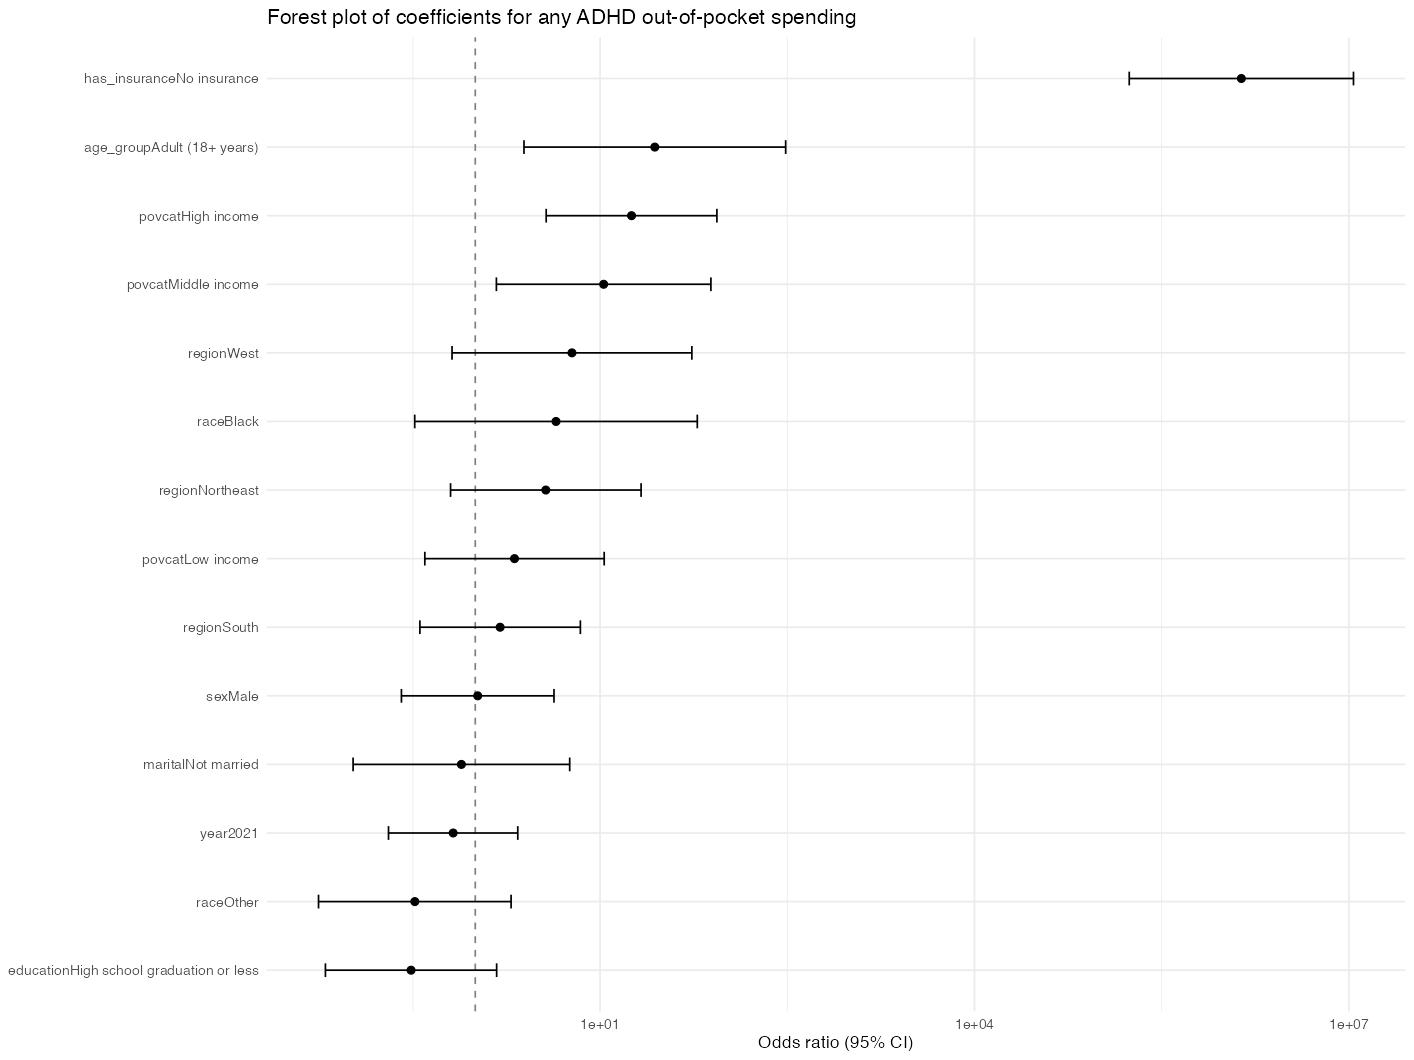

`height` was translated to `width`.

In [88]:
# fit_any <- svyglm(I(oop > 0) ~ post_covid * (age + sex + race + ethnicity +
#                                              marital + education + income +
#                                              poverty + has_insurance),
#                   family = quasibinomial(),
#                   design = meps_design_subset_adhdfills)

test_oop_any <- svyglm(I(adhd_oop > 0) ~ year +  age_group + sex + race + 
                                                 marital + education + povcat + 
                                                 has_insurance + region,
                 family = quasibinomial(),
                 design = design_step5)

summary(test_oop_any)

coef_df <- as.data.frame(summary(test_oop_any)$coefficients) %>%
  tibble::rownames_to_column("term") %>%
  filter(term != "(Intercept)") %>%
  mutate(
    OR = exp(Estimate),
    CI_low = exp(Estimate - 1.96 * `Std. Error`),
    CI_high = exp(Estimate + 1.96 * `Std. Error`)
  )

ggplot(coef_df, aes(y = reorder(term, OR), x = OR)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "gray50") +
  geom_errorbarh(aes(xmin = CI_low, xmax = CI_high), height = 0.2) +
  geom_point(size = 2) +
  scale_x_log10() +
  labs(
    x = "Odds ratio (95% CI)",
    y = NULL,
    title = "Forest plot of coefficients for any ADHD out-of-pocket spending"
  ) +
  theme_minimal()

In [87]:
summary(test_oop_any)


There were 50 or more warnings (use warnings() to see the first 50)



Call:
svyglm(formula = I(adhd_oop > 0) ~ year + year:(age_group + sex + 
    race + marital + education + povcat + has_insurance + region), 
    design = design_step5, family = quasibinomial())

Survey design:
design_step5 <- subset(design, DUPERSID %in% ids_step5)

Coefficients:
                                                 Estimate Std. Error t value Pr(>|t|)
(Intercept)                                        2.2685     3.4009   0.667      NaN
year2021                                         -32.9979     4.1601  -7.932      NaN
year2019:age_groupAdult (18+ years)                3.8768     2.4404   1.589      NaN
year2021:age_groupAdult (18+ years)               31.1694     2.0510  15.197      NaN
year2019:sexMale                                   1.7171     2.0377   0.843      NaN
year2021:sexMale                                   0.5125     0.9365   0.547      NaN
year2019:raceBlack                                 3.7149     2.1166   1.755      NaN
year2021:raceBlack            

There were 49 warnings (use warnings() to see them)
There were 50 or more warnings (use warnings() to see the first 50)


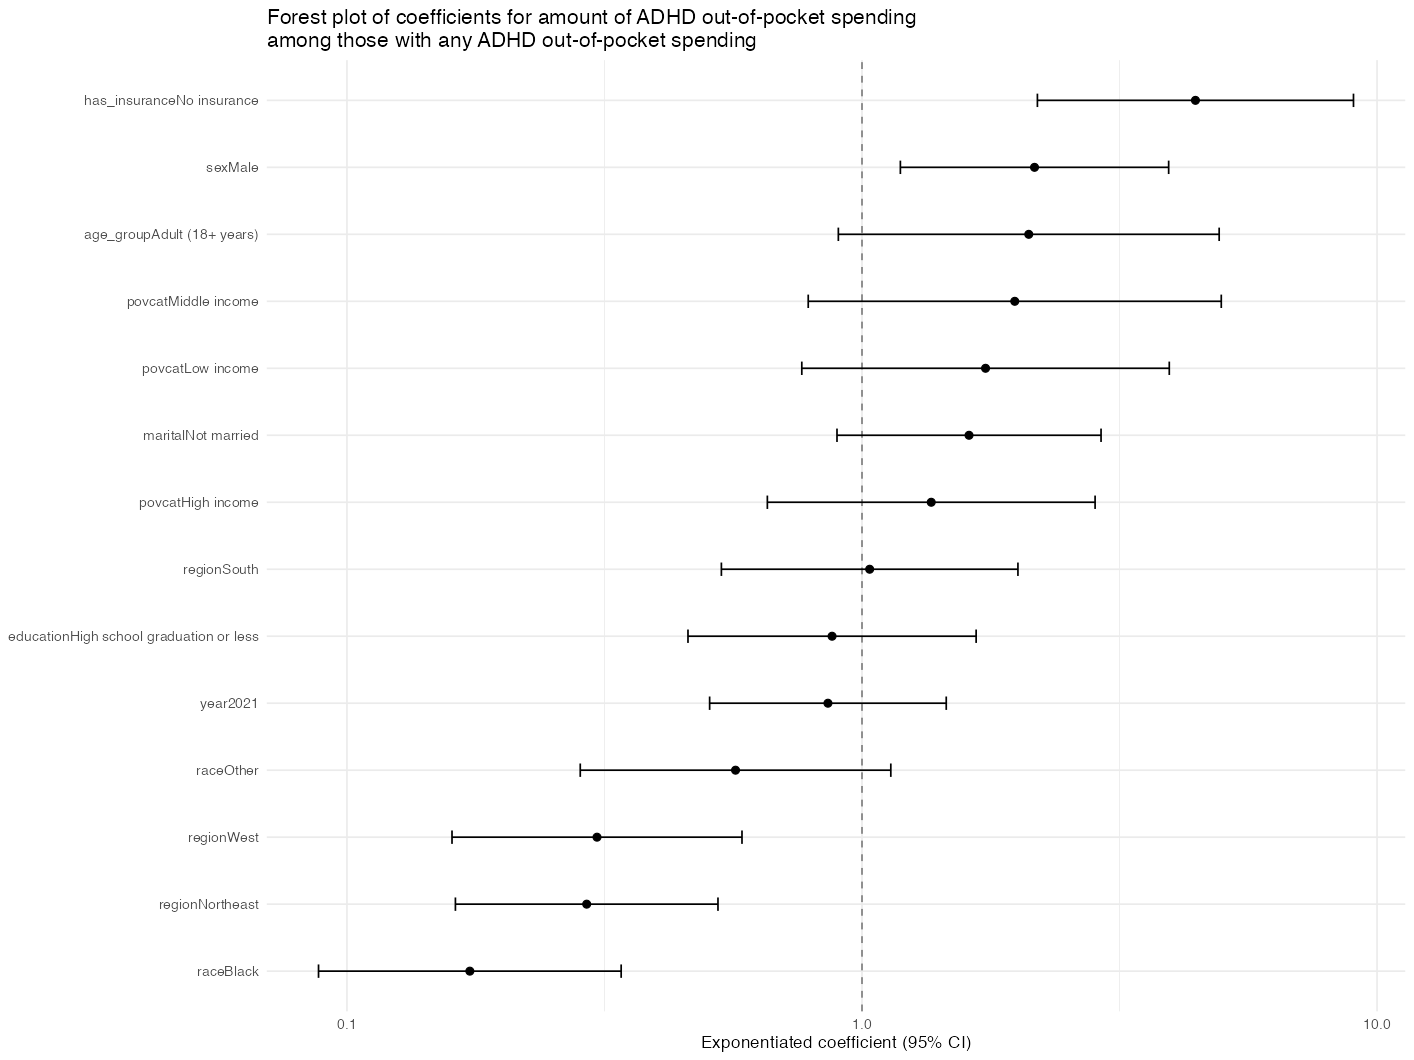

`height` was translated to `width`.

In [89]:
# fit_pos <- svyglm(oop ~ post_covid * (age + sex + race + ethnicity +
#                                       marital + education + income +
#                                       poverty + has_insurance),
#                   family = Gamma(link = "log"),
#                   design = subset(meps_design_subset_adhdfills, oop > 0))

test_oop_pos <- svyglm(adhd_oop ~ year + age_group + sex + race + 
                                                 marital + education + povcat + 
                                                 has_insurance + region,
                 family = Gamma(link = "log"),
                 design = subset(design_step5, adhd_oop > 0))

pos_coef_df <- as.data.frame(summary(test_oop_pos)$coefficients) %>%
  tibble::rownames_to_column("term") %>%
  filter(term != "(Intercept)") %>%
  mutate(
    exp_coef = exp(Estimate),
    CI_low = exp(Estimate - 1.96 * `Std. Error`),
    CI_high = exp(Estimate + 1.96 * `Std. Error`)
  )

ggplot(pos_coef_df, aes(y = reorder(term, exp_coef), x = exp_coef)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "gray50") +
  geom_errorbarh(aes(xmin = CI_low, xmax = CI_high), height = 0.2) +
  geom_point(size = 2) +
  scale_x_log10() +
  labs(
    x = "Exponentiated coefficient (95% CI)",
    y = NULL,
    title = "Forest plot of coefficients for amount of ADHD out-of-pocket spending \namong those with any ADHD out-of-pocket spending"
  ) +
  theme_minimal()

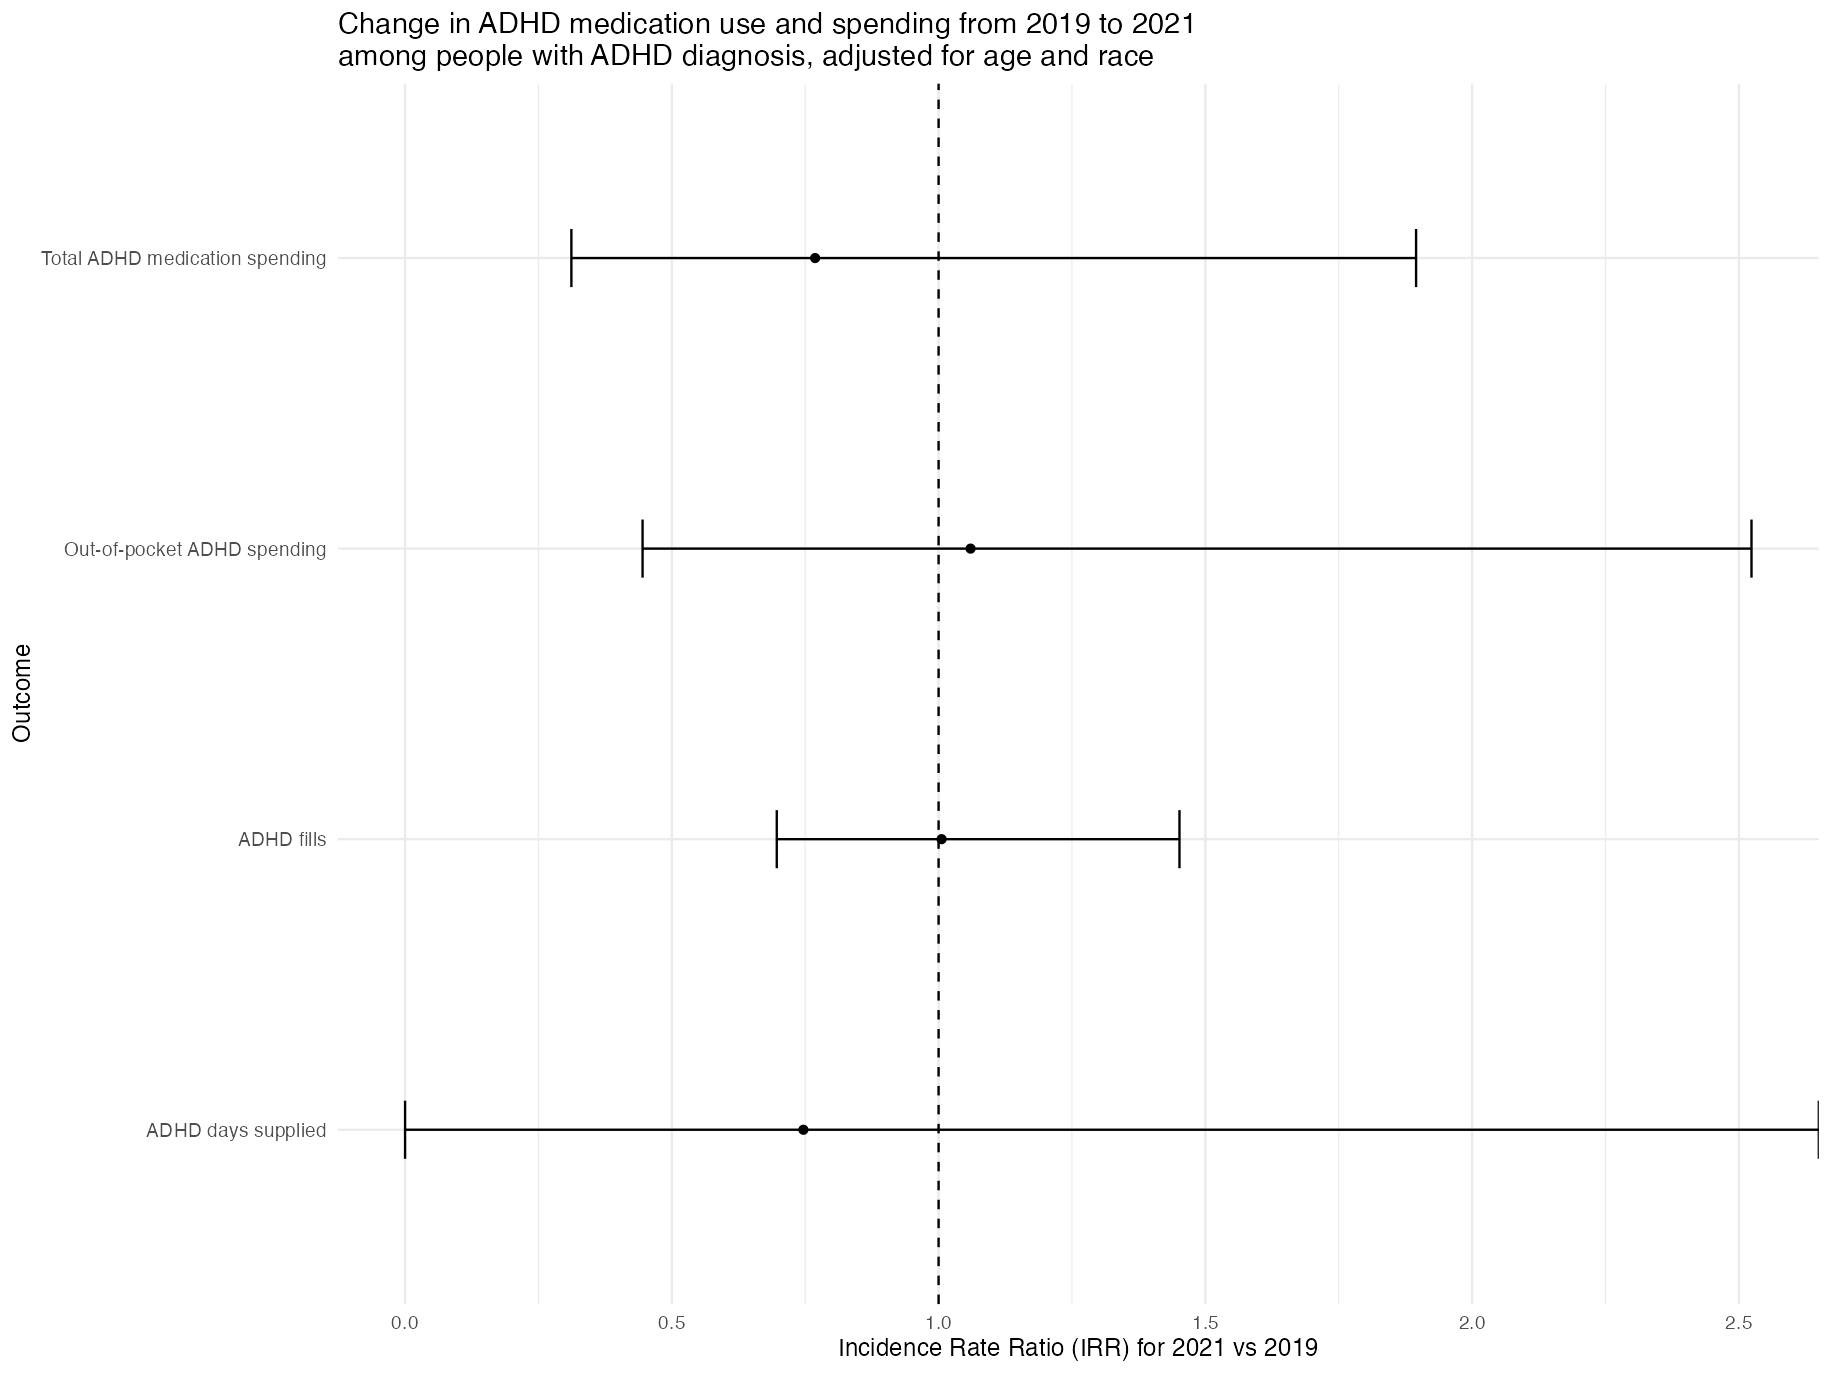

In [53]:
# 2 - adjusted for age and race
m2_fills <- suppressWarnings(svyglm(
  adhd_fills ~ year * race + AGE53X,
  design = design_step4_reg,
  family = quasipoisson()
))

m2_days_supp <- suppressWarnings(svyglm(
  adhd_days_supp ~ year * race + AGE53X,
  design = design_step4_reg,
  family = quasipoisson()
))

m2_total_spend <- suppressWarnings(svyglm(
  adhd_total_spend ~ year * race + AGE53X,
  design = design_step4_reg,
  family = quasipoisson()
))

m2_oop <- suppressWarnings(svyglm(
  adhd_oop ~ year * race + AGE53X,
  design = design_step4_reg,
  family = quasipoisson()
))

results_df_2 <- tibble(
  outcome = c("ADHD fills", "ADHD days supplied", "Total ADHD medication spending", "Out-of-pocket ADHD spending"),
  IRR = c(
    exp(coef(m2_fills)["year2021"]),
    exp(coef(m2_days_supp)["year2021"]),
    exp(coef(m2_total_spend)["year2021"]),
    exp(coef(m2_oop)["year2021"])
  ),
  CI_lower = c(
    exp(confint(m2_fills)["year2021", 1]),
    exp(confint(m2_days_supp)["year2021", 1]),
    exp(confint(m2_total_spend)["year2021", 1]),
    exp(confint(m2_oop)["year2021", 1])
  ),
  CI_upper = c(
    exp(confint(m2_fills)["year2021", 2]),
    exp(confint(m2_days_supp)["year2021", 2]),
    exp(confint(m2_total_spend)["year2021", 2]),
    exp(confint(m2_oop)["year2021", 2])
  )
)

ggplot(results_df_2, aes(x = outcome, y = IRR)) +
  geom_point() +
  geom_errorbar(aes(ymin = CI_lower, ymax = CI_upper), width = 0.2) +
  geom_hline(yintercept = 1, linetype = "dashed") +
  scale_y_continuous(name = "Incidence Rate Ratio (IRR) for 2021 vs 2019", limits = c(0, NA)) +
  xlab("Outcome") +
  ggtitle("Change in ADHD medication use and spending from 2019 to 2021 \namong people with ADHD diagnosis, adjusted for age and race") +
  coord_flip() +
  theme_minimal()

In [49]:
summary(m2_oop)

There were 50 or more warnings (use warnings() to see the first 50)



Call:
svyglm(formula = adhd_oop ~ year * race + AGE53X, design = design_step4_reg, 
    family = quasipoisson())

Survey design:
update(design_step4, year = relevel(year, ref = "2019"))

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)          4.43156    0.41078  10.788 1.90e-06 ***
year2021             0.05820    0.38349   0.152    0.883    
raceBlack           -0.04289    1.17943  -0.036    0.972    
raceOther           -1.25214    1.12630  -1.112    0.295    
AGE53X               0.02709    0.01493   1.815    0.103    
year2021:raceBlack -15.04643    1.23476 -12.186 6.75e-07 ***
year2021:raceOther  -0.86825    0.98850  -0.878    0.403    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for quasipoisson family taken to be 602.4387)

Number of Fisher Scoring iterations: 8


In [24]:
# Regressions: change in ADHD fills from 2019 to 2021 (survey-weighted)

# set 2019 as reference
design_step5_reg <- update(design_step5, year = relevel(year, ref = "2019"))

# 1) Unadjusted count model
m1 <- svyglm(
  adhd_fills ~ year,
  design = design_step5_reg,
  family = quasipoisson(link = "log")
)

# 2) Adjusted model with key covariates
m2 <- svyglm(
  adhd_fills ~ year + age_group + sex + race + education + povcat + insurance_table1 + region,
  design = design_step5_reg,
  family = quasipoisson(link = "log")
)

# 3) Sensitivity model on log-transformed fills
m3 <- svyglm(
  log1p(adhd_fills) ~ year + age_group + sex + race + education + povcat + insurance_table1 + region,
  design = design_step5_reg
)

# helper: extract IRR and 95% CI for year2021 from quasipoisson models
get_irr <- function(model, term = "year2021") {
  b <- coef(model)[term]
  se <- sqrt(diag(vcov(model)))[term]
  out <- tibble(
    term = term,
    estimate = b,
    std_error = se,
    IRR = exp(b),
    CI_low = exp(b - 1.96 * se),
    CI_high = exp(b + 1.96 * se),
    p_value = summary(model)$coefficients[term, "Pr(>|t|)"]
  )
  out
}

irr_m1 <- get_irr(m1)
irr_m2 <- get_irr(m2)

# print core results
cat("\nModel 1 (Unadjusted quasipoisson):\n")
print(summary(m1))
cat("\nDispersion (m1):", summary(m1)$dispersion, "\n")
print(irr_m1)

cat("\nModel 2 (Adjusted quasipoisson):\n")
print(summary(m2))
cat("\nDispersion (m2):", summary(m2)$dispersion, "\n")
print(irr_m2)

cat("\nModel 3 (Sensitivity: log1p linear model):\n")
print(summary(m3))

There were 37 warnings (use warnings() to see them)
There were 28 warnings (use warnings() to see them)
There were 28 warnings (use warnings() to see them)
There were 50 or more warnings (use warnings() to see the first 50)
There were 50 or more warnings (use warnings() to see the first 50)



Model 1 (Unadjusted quasipoisson):

Call:
svyglm(formula = adhd_fills ~ year, design = design_step5_reg, 
    family = quasipoisson(link = "log"))

Survey design:
update(design_step5, year = relevel(year, ref = "2019"))

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.75042    0.10774  16.247 3.36e-12 ***
year2021    -0.01134    0.14720  -0.077    0.939    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for quasipoisson family taken to be 3.613081)

Number of Fisher Scoring iterations: 5



There were 50 or more warnings (use warnings() to see the first 50)



Dispersion (m1): 3.613081 


There were 50 or more warnings (use warnings() to see the first 50)


...

There were 50 or more warnings (use warnings() to see the first 50)



Dispersion (m2): 2.131391 


There were 50 or more warnings (use warnings() to see the first 50)


# A tibble: 1 × 7
  term     estimate std_error   IRR CI_low CI_high p_value
  <chr>       <dbl>     <dbl> <dbl>  <dbl>   <dbl>   <dbl>
1 year2021   0.0205     0.210  1.02  0.677    1.54     NaN

Model 3 (Sensitivity: log1p linear model):

Call:
svyglm(formula = log1p(adhd_fills) ~ year + age_group + sex + 
    race + education + povcat + insurance_table1 + region, design = design_step5_reg)

Survey design:
update(design_step5, year = relevel(year, ref = "2019"))

Coefficients:
                                         Estimate Std. Error t value Pr(>|t|)
(Intercept)                              2.599377   0.453629   5.730      NaN
year2021                                -0.052038   0.169682  -0.307      NaN
age_groupAdult (18+ years)              -0.241873   0.263250  -0.919      NaN
sexMale                                  0.101898   0.155785   0.654      NaN
raceBlack                               -0.707018   0.314216  -2.250      NaN
raceOther                               -0.428588

There were 50 or more warnings (use warnings() to see the first 50)


In [25]:
degf(design_step5_reg)

[1] 19